**1. Problem Formulation**
    
    This milestone focuses on Geospatial Data Analysis and Exploratory Data Analysis (EDA) to analyze and visualize the geographical distribution of natural disaster declarations across the United States. The objective is to convert aggregated data into maps and spatial visualizations to reveal patterns that cannot be observed in tabular data.

**This analysis aims to answer several key questions:**
    
    Which states have the highest number of disaster declarations? 
    
    Are disasters concentrated in certain regions?
    
    Do specific incident types occur more frequently in specific states?
    
    Can geographical hotspots be identified? 

In [87]:
# --- STEP 2: Dataset Preparation ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import folium
import geopandas as gpd

df = pd.read_csv('../data/usnd_cleaned.csv')

required_cols = ['state', 'incidentType', 'year', 'month']
print("Required Columns Present:", all(col in df.columns for col in required_cols))

df['state'] = df['state'].astype(str).str.upper().str.strip()

missing_vals = df[['state', 'incidentType']].isnull().sum()
print("Missing values in Geographic columns:\n", missing_vals)

df = df.dropna(subset=['state', 'incidentType'])

Required Columns Present: True
Missing values in Geographic columns:
 state           0
incidentType    0
dtype: int64


In [88]:
state_summary = df.groupby('state').size().reset_index(name='disasterCount')

state_summary = state_summary.sort_values(by='disasterCount', ascending=False)

print("3.1 State-Level Aggregation Results:")
print(state_summary.head(10))

3.1 State-Level Aggregation Results:
   state  disasterCount
50    TX           3842
28    MO           2263
20    KY           2026
52    VA           1982
41    OK           1882
10    FL           1512
15    IA           1471
12    GA           1406
21    LA           1393
32    NC           1312


In [89]:
state_incident_summary = df.groupby(['state', 'incidentType']).size().reset_index(name='count')

state_incident_summary = state_incident_summary.sort_values(by='count', ascending=False)

print("\n3.2 State + Incident Type Aggregation Results:")
print(state_incident_summary.head(10))


3.2 State + Incident Type Aggregation Results:
    state incidentType  count
203    MO        Storm   1203
346    TX    Hurricane   1151
344    TX         Fire   1118
295    OK        Storm    903
142    KY        Storm    898
133    KS        Storm    848
349    TX        Storm    802
224    NC    Hurricane    772
147    LA    Hurricane    740
341    TN        Storm    689


In [90]:
region_to_states = {
    'Northeast': ['CT', 'ME', 'MA', 'NH', 'RI', 'VT', 'NJ', 'NY', 'PA'],
    'Midwest': ['IL', 'IN', 'IA', 'KS', 'MI', 'MN', 'MS', 'NE', 'ND', 'OH', 'SD', 'WI'],
    'South': ['AL', 'AR', 'DE', 'FL', 'GA', 'KY', 'LA', 'MD', 'MS', 'NC', 'OK', 'SC', 'TN', 'TX', 'VA', 'WV'],
    'West': ['AK', 'AZ', 'CA', 'CO', 'HI', 'ID', 'MT', 'NV', 'NM', 'OR', 'UT', 'WA', 'WY']
}

state_to_region = {state: region for region, states in region_to_states.items() for state in states}

df['region'] = df['state'].map(state_to_region)

region_summary = df.groupby('region').size().reset_index(name='disasterCount')
region_summary = region_summary.sort_values(by='disasterCount', ascending=False)

print("3.3 Regional Comparison Results:")
print(region_summary)

3.3 Regional Comparison Results:
      region  disasterCount
2      South          22349
0    Midwest          11627
1  Northeast           4319
3       West           4232


In [91]:
fig = px.choropleth(state_summary, 
                    locations='state', 
                    locationmode="USA-states", 
                    color='disasterCount',
                    scope="usa",
                    color_continuous_scale="Reds",
                    labels={'disasterCount':'Total Declarations'},
                    title='4.1 US Disaster Hotspots: Choropleth Map (1953-2017)')

fig.show()

**4.1 Nationwide Disaster Distribution (Plotly Map)**

Represents: The total frequency of all federal disaster declarations across the 50 US states using a continuous color scale.

Spatial Pattern: High-intensity clusters in the South (Texas/Florida) and the West (California).

Explanation: These states have the largest landmasses and are situated in high-risk environmental zones like the Gulf Coast and the Pacific wildfire corridors.

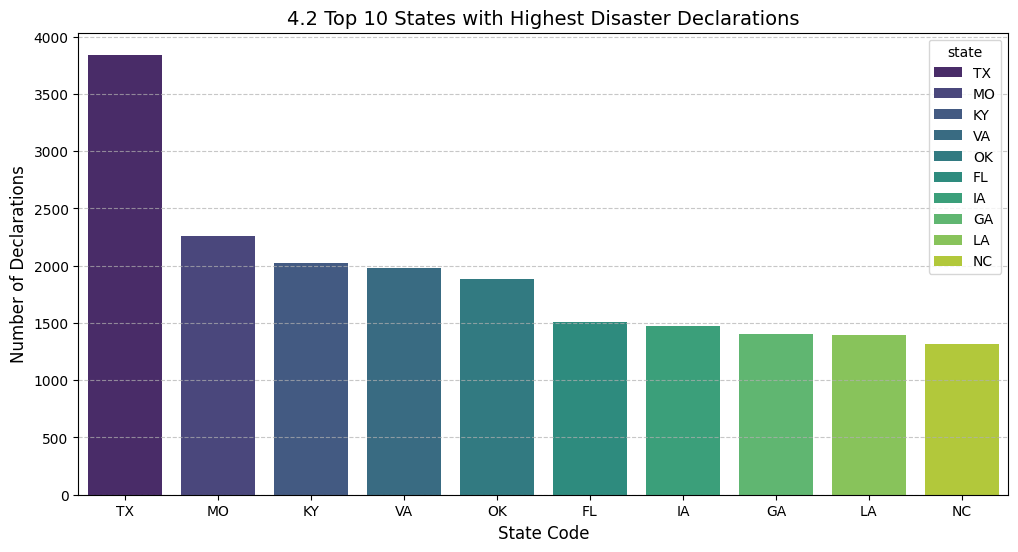

In [92]:
plt.figure(figsize=(12, 6))

sns.barplot(data=state_summary.head(10), 
            x='state', 
            y='disasterCount', 
            hue='state', 
            palette='viridis', 
            legend=True)

plt.title('4.2 Top 10 States with Highest Disaster Declarations', fontsize=14)
plt.xlabel('State Code', fontsize=12)
plt.ylabel('Number of Declarations', fontsize=12)

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

**4.2 Top 10 States Comparison (Seaborn Bar Chart)**

Represents: A direct comparison of the ten states with the highest total disaster counts.

Spatial Pattern: Texas is a clear national outlier, followed by a secondary group of states (KY, MO, FL) with remarkably similar counts.

Explanation: Texas's massive size crosses multiple climate zones. The similarity in KY and MO reflects shared regional vulnerability to Mississippi and Ohio River basin flooding.

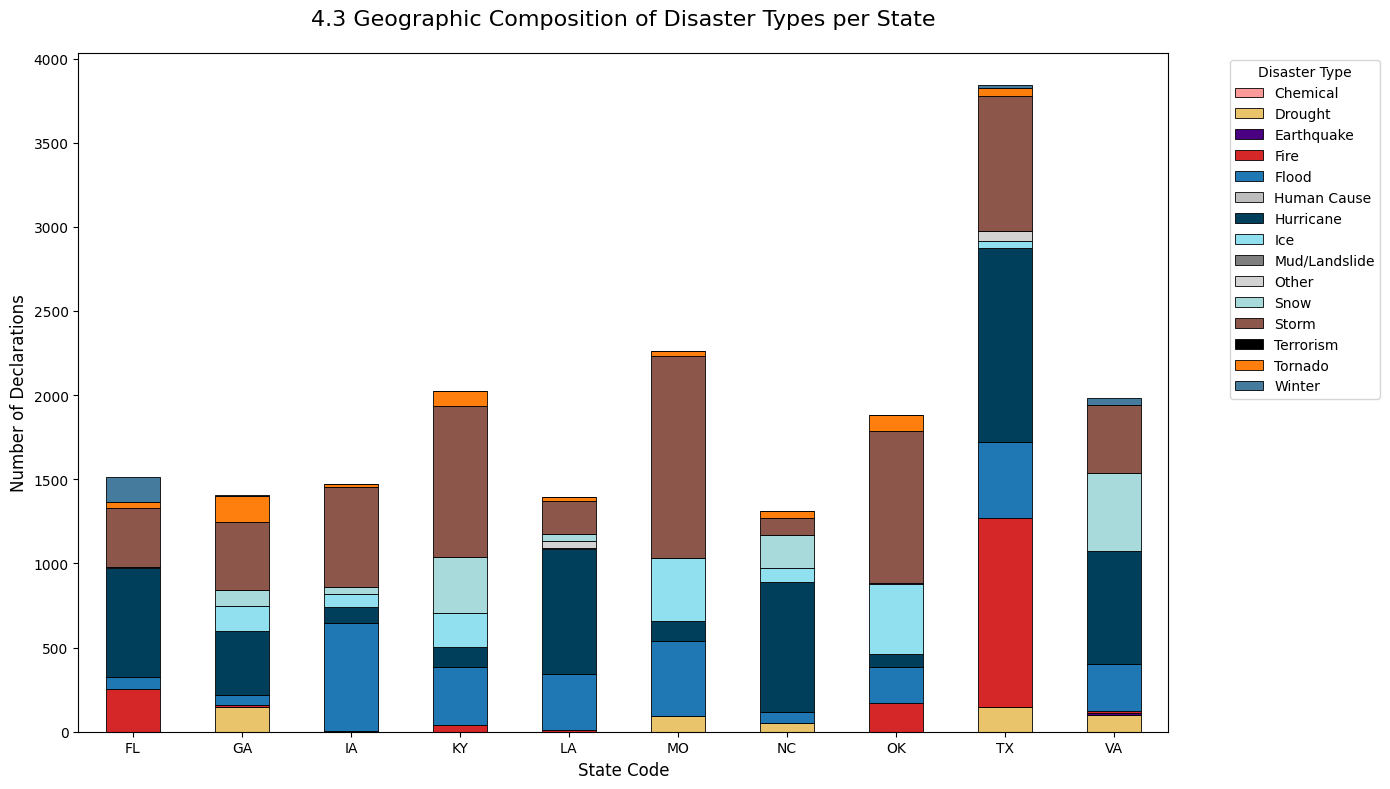

In [93]:
colors = {
    'Fire': '#d62728',
    'Flood': '#1f77b4',
    'Hurricane': '#003f5c', 
    'Severe Storm': '#9467bd', 
    'Storm': '#8c564b',  
    'Snow': '#a8dadc',  
    'Tornado': '#ff7f0e', 
    'Winter': '#457b9d',  
    'Drought': '#e9c46a', 
    'Earthquake': '#4B0082',  
    'Coastal Storm': '#2ca02c', 
    'Mud/Landslide': '#7f7f7f', 
    'Ice': '#90e0ef',           
    'Severe Ice Storm': '#00b4d8',
    'Chemical': '#fb9a99',     
    'Other': '#d3d3d3',       
    'Terrorism': '#000000'     
}

top_10_list = state_summary.head(10)['state'].tolist()
stacked_data = state_incident_summary[state_incident_summary['state'].isin(top_10_list)]
pivot_df = stacked_data.pivot(index='state', columns='incidentType', values='count').fillna(0)

plot_colors = [colors.get(col, '#bdbdbd') for col in pivot_df.columns]

ax = pivot_df.plot(kind='bar', 
                   stacked=True, 
                   figsize=(14, 8), 
                   color=plot_colors, 
                   edgecolor='black', 
                   linewidth=0.6)

plt.title('4.3 Geographic Composition of Disaster Types per State', fontsize=16, pad=20)
plt.xlabel('State Code', fontsize=12)
plt.ylabel('Number of Declarations', fontsize=12)

plt.xticks(rotation=0) 

plt.legend(title='Disaster Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

**4.3 Geographic Composition of Disaster Types per State**

Represents: The proportional mix of 15+ disaster categories within the top 10 most disaster-prone states, using intuitive manual color mapping.

Spatial Pattern: TX shows a massive volume of Fire (Red) and Hurricanes (Dark Blue). Inland states like MO and OK are dominated by Storms (Brown), while VA and KY show significant Snow/Ice (Light Blue) segments.

Explanation: Patterns are driven by climate zones. The Gulf Coast/Atlantic states face tropical systems, while the Great Plains/Midwest are susceptible to continental storm systems and temperature-driven ice events.

In [94]:
import geopandas as gpd
import folium

usa = gpd.read_file("https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json")

state_name_map = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas', 'CA': 'California',
    'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware', 'FL': 'Florida', 'GA': 'Georgia',
    'HI': 'Hawaii', 'ID': 'Idaho', 'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa',
    'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi',
    'MO': 'Missouri', 'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada', 'NH': 'New Hampshire',
    'NJ': 'New Jersey', 'NM': 'New Mexico', 'NY': 'New York', 'NC': 'North Carolina',
    'ND': 'North Dakota', 'OH': 'Ohio', 'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania',
    'RI': 'Rhode Island', 'SC': 'South Carolina', 'SD': 'South Dakota', 'TN': 'Tennessee',
    'TX': 'Texas', 'UT': 'Utah', 'VT': 'Vermont', 'VA': 'Virginia', 'WA': 'Washington',
    'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming'
}

target_incident = 'Hurricane'
incident_data = state_incident_summary[state_incident_summary['incidentType'] == target_incident].copy()

incident_data['state_full'] = incident_data['state'].map(state_name_map)

map_df = usa.merge(incident_data, left_on='name', right_on='state_full', how='left').fillna(0)

#Create Folium Map
m = folium.Map(location=[37.8, -96], zoom_start=4, tiles='CartoDB positron')

folium.Choropleth(
    geo_data=usa,
    name='Hurricane Hotspots',
    data=map_df,
    columns=['name', 'count'],
    key_on='feature.properties.name',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name=f'Total {target_incident} Declarations'
).add_to(m)

#Render map
m

**4.4 Specific Incident Hotspot (Folium Map)**

Represents: An interactive geospatial intensity map focusing specifically on Hurricane declarations, linking FEMA data to physical state boundaries using GeoPandas and Folium.

Spatial Pattern: A high-intensity "hotspot" is concentrated along the Gulf Coast (FL, TX, LA) and the Southeastern Atlantic Seaboard (NC, SC), while inland and Western states show zero activity.

Explanation: Hurricanes are geographically restricted by water temperature and atmospheric tracks. The warm waters of the Gulf of Mexico and the Atlantic serve as fuel, making coastal states primary targets for landfall, unlike landlocked regions.